In [2]:
import ipywidgets as widgets
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import wot

### let's unpickle it!

import pickle

with open('schiebinger_data.pkl', 'rb') as f:
    Xs = pickle.load(f)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "/Users/noahbergam/Desktop/cs-misc/intrinsicDimension/dim-est-env/lib/python3.9/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/noahbergam/Desktop/cs-misc/intrinsicDimen

In [3]:
### let's unpickle it!

import pickle

with open('schiebinger_data.pkl', 'rb') as f:
    Xs = pickle.load(f)

number of time steps:  19
embedding dimension:  19089


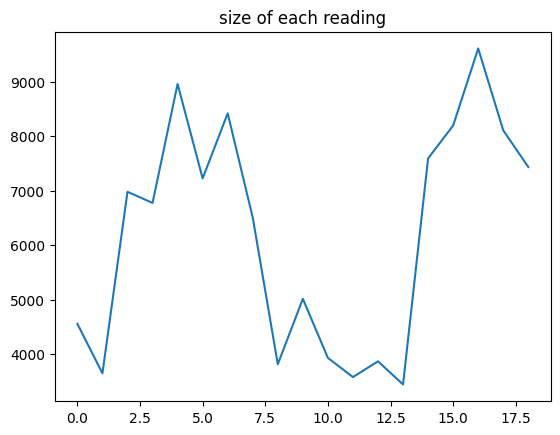

In [4]:
lens = [X.shape[0] for X in Xs]
plt.plot(lens)
plt.title('size of each reading')

print('number of time steps: ', len(Xs))
print('embedding dimension: ', Xs[1].shape[1])

In [ ]:
vars = [np.var(X.todense()) for X in Xs]

Text(0.5, 1.0, 'variance of each reading')

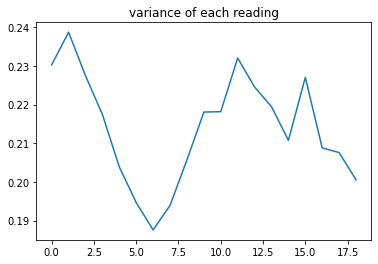

In [ ]:
plt.plot(vars)
plt.title('variance of each reading')

In [ ]:
def approximate_rank(A, tol=0.1):
    # Singular values
    s = np.linalg.svd(A, compute_uv=False)
    
    return np.sum(s > tol)
approximate_rank(Xs[0].todense(), tol=0.1)

4556

In [ ]:
from sklearn.utils.extmath import randomized_svd

svds = []

for X in Xs:
    U, s, Vt = randomized_svd(X, n_components=100, random_state=0)
    svds.append(s)
#tol = np.max(A.shape) * np.finfo(s.dtype).eps * s[0]
#rank_est = np.sum(s > tol)
#print("Approximate rank:", rank_est)

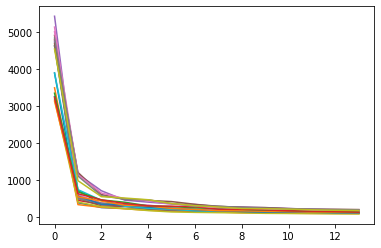

In [ ]:
for i in range(len(Xs)):
    plt.plot(svds[i][:1])


Text(0.5, 1.0, 'effective rank (based on top 100 singular values)')

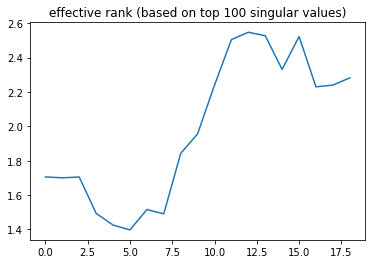

In [ ]:
def effective_rank(s):
    p = (s**2) / np.sum(s**2)
    return np.exp(-np.sum(p * np.log(p + 1e-12)))
effective_ranks = [effective_rank(svds[i]) for i in range(len(Xs))]
plt.plot(effective_ranks)
plt.title('effective rank (based on top 100 singular values)')

<ipython-input-51-e0b8ccdc39c1>:27: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axs[0].scatter(X_pca[:, 0], X_pca[:, 1], cmap="tab10", s=30)
<ipython-input-51-e0b8ccdc39c1>:31: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axs[1].scatter(X_tsne[:, 0], X_tsne[:, 1], cmap="tab10", s=30)


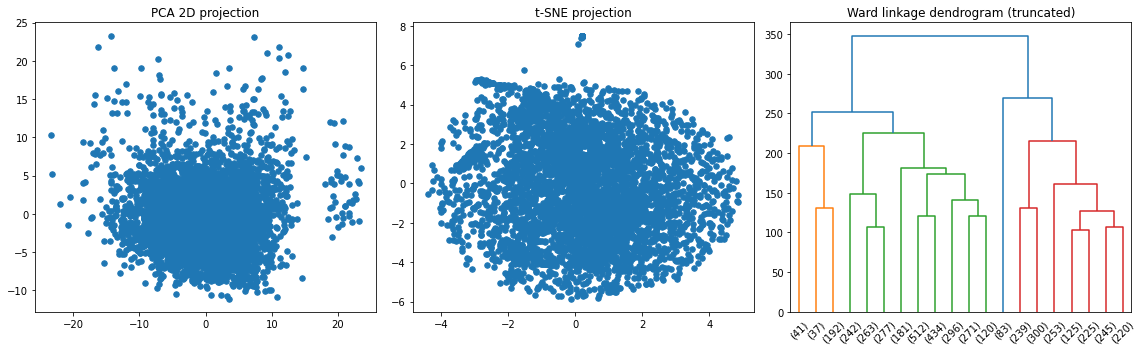

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

X = Xs[0].todense()
X = np.asarray(X)

# ---- 2. PCA projection (2D) ----
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# ---- 3. t-SNE projection (2D) ----
X_tsne = TSNE(n_components=2, random_state=42, init="pca", learning_rate="auto").fit_transform(X)

# ---- 4. Ward hierarchical clustering ----
Z = linkage(X, method="ward")  # linkage matrix
# Cut tree into k clusters (say 4 to match ground truth)
labels_ward = fcluster(Z, t=4, criterion="maxclust")

# ---- 5. Visualization ----
fig, axs = plt.subplots(1, 3, figsize=(16, 5))

# PCA
axs[0].scatter(X_pca[:, 0], X_pca[:, 1], cmap="tab10", s=30)
axs[0].set_title("PCA 2D projection")

# t-SNE
axs[1].scatter(X_tsne[:, 0], X_tsne[:, 1], cmap="tab10", s=30)
axs[1].set_title("t-SNE projection")

# Ward dendrogram
dendrogram(Z, truncate_mode="lastp", p=20, leaf_rotation=45, leaf_font_size=10, ax=axs[2])
axs[2].set_title("Ward linkage dendrogram (truncated)")

plt.tight_layout()
plt.show()

<ipython-input-52-ae21786c2d87>:27: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axs[0].scatter(X_pca[:, 0], X_pca[:, 1], cmap="tab10", s=30)
<ipython-input-52-ae21786c2d87>:31: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axs[1].scatter(X_tsne[:, 0], X_tsne[:, 1], cmap="tab10", s=30)


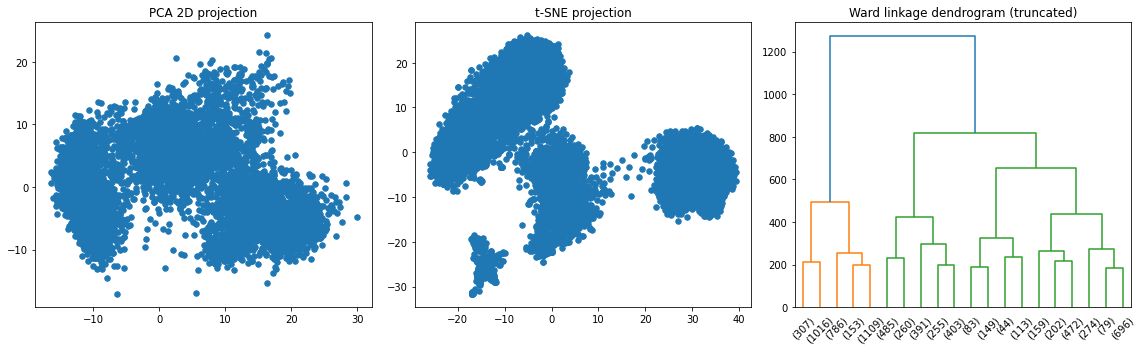

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

X = Xs[-1].todense()
X = np.asarray(X)

# ---- 2. PCA projection (2D) ----
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# ---- 3. t-SNE projection (2D) ----
X_tsne = TSNE(n_components=2, random_state=42, init="pca", learning_rate="auto").fit_transform(X)

# ---- 4. Ward hierarchical clustering ----
Z = linkage(X, method="ward")  # linkage matrix
# Cut tree into k clusters (say 4 to match ground truth)
labels_ward = fcluster(Z, t=4, criterion="maxclust")

# ---- 5. Visualization ----
fig, axs = plt.subplots(1, 3, figsize=(16, 5))

# PCA
axs[0].scatter(X_pca[:, 0], X_pca[:, 1], cmap="tab10", s=30)
axs[0].set_title("PCA 2D projection")

# t-SNE
axs[1].scatter(X_tsne[:, 0], X_tsne[:, 1], cmap="tab10", s=30)
axs[1].set_title("t-SNE projection")

# Ward dendrogram
dendrogram(Z, truncate_mode="lastp", p=20, leaf_rotation=45, leaf_font_size=10, ax=axs[2])
axs[2].set_title("Ward linkage dendrogram (truncated)")

plt.tight_layout()
plt.show()

<ipython-input-4-fe54605a1e5e>:27: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axs[0].scatter(X_pca[:, 0], X_pca[:, 1], cmap="tab10", s=30)
<ipython-input-4-fe54605a1e5e>:31: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axs[1].scatter(X_tsne[:, 0], X_tsne[:, 1], cmap="tab10", s=30)


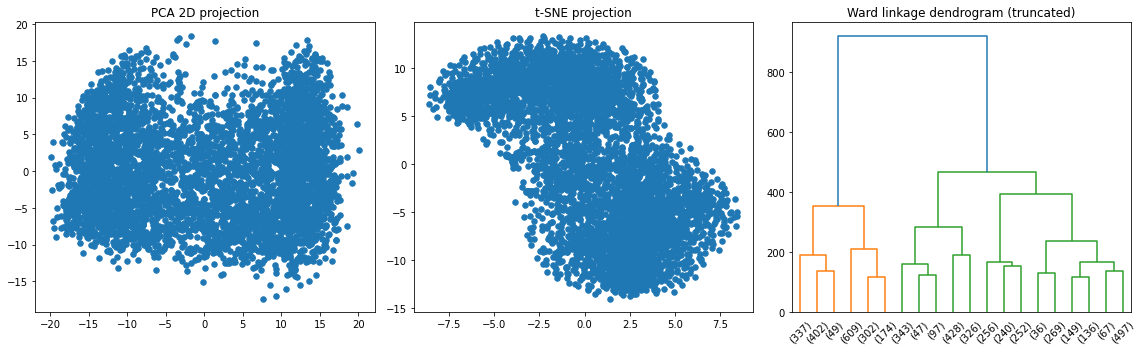

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

X = Xs[9].todense()
X = np.asarray(X)

# ---- 2. PCA projection (2D) ----
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# ---- 3. t-SNE projection (2D) ----
X_tsne = TSNE(n_components=2, random_state=42, init="pca", learning_rate="auto").fit_transform(X)

# ---- 4. Ward hierarchical clustering ----
Z = linkage(X, method="ward")  # linkage matrix
# Cut tree into k clusters (say 4 to match ground truth)
labels_ward = fcluster(Z, t=4, criterion="maxclust")

# ---- 5. Visualization ----
fig, axs = plt.subplots(1, 3, figsize=(16, 5))

# PCA
axs[0].scatter(X_pca[:, 0], X_pca[:, 1], cmap="tab10", s=30)
axs[0].set_title("PCA 2D projection")

# t-SNE
axs[1].scatter(X_tsne[:, 0], X_tsne[:, 1], cmap="tab10", s=30)
axs[1].set_title("t-SNE projection")

# Ward dendrogram
dendrogram(Z, truncate_mode="lastp", p=20, leaf_rotation=45, leaf_font_size=10, ax=axs[2])
axs[2].set_title("Ward linkage dendrogram (truncated)")

plt.tight_layout()
plt.show()